# 03 — Recommender Evaluation

Measure recommendation quality on simulated users:

- **Leave-one-out seed recovery** — drop one seed song, rebuild the profile from the rest, check whether the held-out song appears near the top of the recs (Hit Rate@K, MRR, mean rank).
- **Genre consistency** — fraction of recs whose genre matches the seed (with sparse genres bucketed into `"other"`).
- **Intra-list diversity** — how varied the rec list is internally.
- **Hidden gem rate** — fraction of recs that survive the gems filter.

Two populations: random seeds (eclectic) vs genre-coherent seeds (focused). Both N = 200 users × 5 seed songs.

## 1. Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_dataset, scale_features
from src.features import AUDIO_FEATURES
from src.recommend import recommend
from src.hidden_gems import hidden_gems
from src.evaluation import leave_one_out, genre_consistency, intra_list_diversity

sns.set_theme(style="whitegrid")
RNG = 42
rng = np.random.default_rng(RNG)

df = load_dataset()
scaled, _ = scale_features(df)
print(f"catalog: {len(scaled):,} tracks")

catalog: 4,494 tracks


## 2. Sampling strategy

- **random** — uniform sample of 5 tracks per simulated user (eclectic listener).
- **genre-coherent** — pick a single genre with ≥ 5 tracks, then 5 tracks from it (focused listener).

In [2]:
N_USERS = 200
SEED_SIZE = 5

def sample_random(catalog, n_users, seed_size, rng):
    out = []
    idx_array = catalog.index.to_numpy()
    for _ in range(n_users):
        sel = rng.choice(idx_array, size=seed_size, replace=False)
        out.append(catalog.loc[sel])
    return out

def sample_genre_coherent(catalog, n_users, seed_size, rng, col="playlist_genre"):
    counts = catalog[col].value_counts()
    valid_genres = counts[counts >= seed_size].index.tolist()
    out = []
    for _ in range(n_users):
        g = str(rng.choice(valid_genres))
        pool = catalog[catalog[col] == g]
        sel = rng.choice(pool.index.to_numpy(), size=seed_size, replace=False)
        out.append(catalog.loc[sel])
    return out

random_seeds = sample_random(scaled, N_USERS, SEED_SIZE, rng)
genre_seeds = sample_genre_coherent(scaled, N_USERS, SEED_SIZE, rng)
print(f"random users: {len(random_seeds)} | genre-coherent users: {len(genre_seeds)}")

random users: 200 | genre-coherent users: 200


## 3. Run all metrics per simulated user

In [3]:
K_REC = 10
K_LOO = 10

def evaluate_strategy(seeds_list, catalog):
    rows = []
    for seed in seeds_list:
        loo = leave_one_out(catalog, seed, k=K_LOO)
        recs = recommend(catalog, seed, n=K_REC, alpha=0.85)
        gems = hidden_gems(catalog, seed, top_pct=0.10, n=K_REC)
        rec_ids = set(recs.index)
        gem_ids = set(gems.index)
        rows.append({
            "loo_hit10": loo["hit_rate_at_k"],
            "loo_mean_rank": loo["mean_rank"],
            "loo_ranks": loo["ranks"],
            "genre_consistency": genre_consistency(recs, seed, catalog=catalog),
            "intra_list_diversity": intra_list_diversity(recs),
            "gem_overlap": len(rec_ids & gem_ids) / max(len(rec_ids), 1),
            "n_gems": len(gems),
        })
    return pd.DataFrame(rows)

random_eval = evaluate_strategy(random_seeds, scaled)
genre_eval = evaluate_strategy(genre_seeds, scaled)
print("random_eval rows:", len(random_eval), "| genre_eval rows:", len(genre_eval))

random_eval rows: 200 | genre_eval rows: 200


## 4. Leave-one-out: Hit Rate, MRR, rank distribution

In [4]:
def loo_summary(name, df_eval, n_catalog):
    all_ranks = np.array([r for ranks in df_eval["loo_ranks"] for r in ranks])
    return {
        "strategy": name,
        "held_out_total": int(all_ranks.size),
        "hit@5":  float((all_ranks <= 5).mean()),
        "hit@10": float((all_ranks <= 10).mean()),
        "hit@20": float((all_ranks <= 20).mean()),
        "hit@50": float((all_ranks <= 50).mean()),
        "MRR":    float(np.mean(1.0 / all_ranks)),
        "median_rank": float(np.median(all_ranks)),
        "mean_rank":   float(np.mean(all_ranks)),
        "random_mean_rank_baseline": (n_catalog + 1) / 2,
    }

loo_table = pd.DataFrame([
    loo_summary("random", random_eval, len(scaled)),
    loo_summary("genre-coherent", genre_eval, len(scaled)),
])
loo_table.set_index("strategy").round(4)

,held_out_total,hit@5,hit@10,hit@20,hit@50,MRR,median_rank,mean_rank,random_mean_rank_baseline
strategy,,,,,,,,,
random,1000,0.001,0.001,0.002,0.006,0.0015,2233.5,2278.322,2247.5
genre-coherent,1000,0.012,0.016,0.033,0.066,0.0104,950.5,1280.618,2247.5


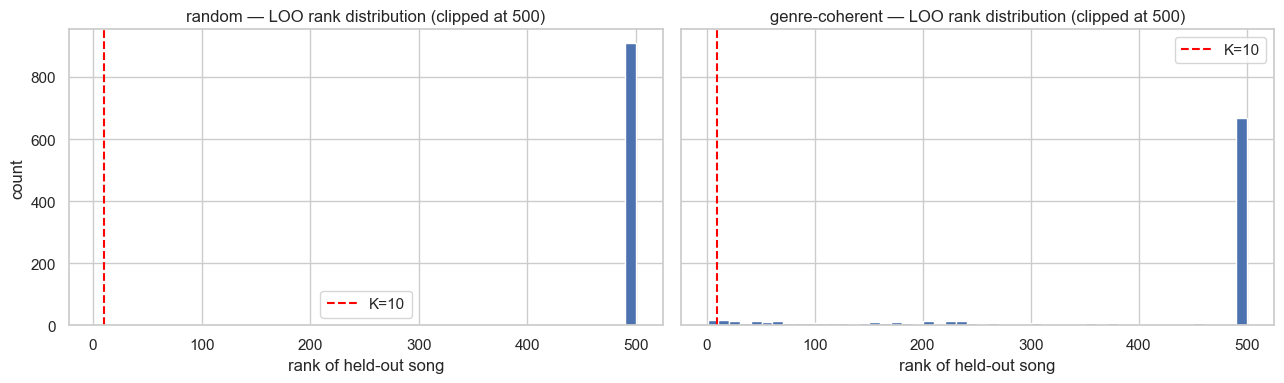

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, label, ev in zip(axes, ["random", "genre-coherent"], [random_eval, genre_eval]):
    ranks = np.array([r for rs in ev["loo_ranks"] for r in rs])
    ax.hist(np.clip(ranks, 1, 500), bins=50, color="C0")
    ax.axvline(10, color="red", ls="--", label="K=10")
    ax.set_title(f"{label} \u2014 LOO rank distribution (clipped at 500)")
    ax.set_xlabel("rank of held-out song"); ax.legend()
axes[0].set_ylabel("count")
plt.tight_layout(); plt.show()

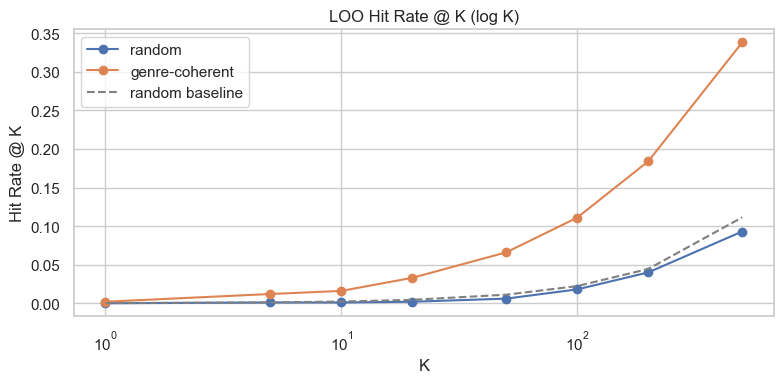

In [6]:
k_curve = np.array([1, 5, 10, 20, 50, 100, 200, 500])
fig, ax = plt.subplots(figsize=(8, 4))
for label, ev in [("random", random_eval), ("genre-coherent", genre_eval)]:
    ranks = np.array([r for rs in ev["loo_ranks"] for r in rs])
    hits = [(ranks <= k).mean() for k in k_curve]
    ax.plot(k_curve, hits, marker="o", label=label)
ax.plot(k_curve, k_curve / len(scaled), ls="--", color="gray", label="random baseline")
ax.set_xscale("log"); ax.set_xlabel("K"); ax.set_ylabel("Hit Rate @ K")
ax.set_title("LOO Hit Rate @ K (log K)")
ax.legend(); plt.tight_layout(); plt.show()

## 5. Genre consistency, intra-list diversity, hidden-gem overlap

In [7]:
def quality_summary(name, df_eval):
    return {
        "strategy": name,
        "genre_consistency_mean":  float(df_eval["genre_consistency"].mean()),
        "genre_consistency_median": float(df_eval["genre_consistency"].median()),
        "ild_mean": float(df_eval["intra_list_diversity"].mean()),
        "ild_median": float(df_eval["intra_list_diversity"].median()),
        "gem_overlap_mean": float(df_eval["gem_overlap"].mean()),
        "avg_n_gems": float(df_eval["n_gems"].mean()),
    }

quality_table = pd.DataFrame([
    quality_summary("random", random_eval),
    quality_summary("genre-coherent", genre_eval),
])
quality_table.set_index("strategy").round(4)

,genre_consistency_mean,genre_consistency_median,ild_mean,ild_median,gem_overlap_mean,avg_n_gems
strategy,,,,,,
random,0.387,0.2,0.0319,0.0274,0.0010,10.0
genre-coherent,0.083,0.0,0.0258,0.0245,0.0015,10.0


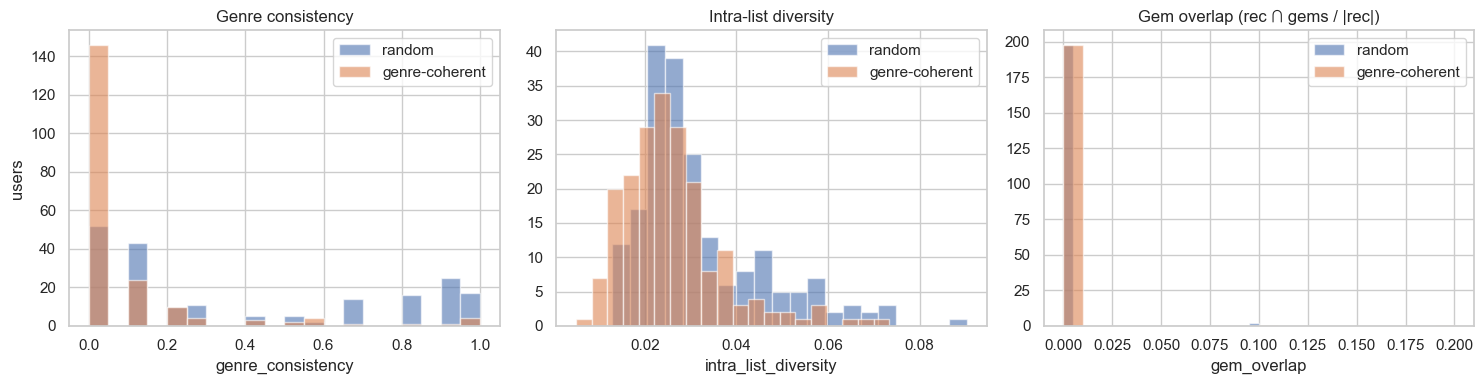

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axes,
    ["genre_consistency", "intra_list_diversity", "gem_overlap"],
    ["Genre consistency", "Intra-list diversity", "Gem overlap (rec \u2229 gems / |rec|)"],
):
    ax.hist(random_eval[col], bins=20, alpha=0.6, label="random")
    ax.hist(genre_eval[col], bins=20, alpha=0.6, label="genre-coherent")
    ax.set_title(title); ax.set_xlabel(col); ax.legend()
axes[0].set_ylabel("users")
plt.tight_layout(); plt.show()

## 6. Summary table

In [9]:
summary = pd.concat(
    [loo_table.set_index("strategy"), quality_table.set_index("strategy")],
    axis=1,
)
summary.round(4)

,held_out_total,hit@5,hit@10,hit@20,hit@50,MRR,median_rank,mean_rank,random_mean_rank_baseline,genre_consistency_mean,genre_consistency_median,ild_mean,ild_median,gem_overlap_mean,avg_n_gems
strategy,,,,,,,,,,,,,,,
random,1000,0.001,0.001,0.002,0.006,0.0015,2233.5,2278.322,2247.5,0.387,0.2,0.0319,0.0274,0.0010,10.0
genre-coherent,1000,0.012,0.016,0.033,0.066,0.0104,950.5,1280.618,2247.5,0.083,0.0,0.0258,0.0245,0.0015,10.0


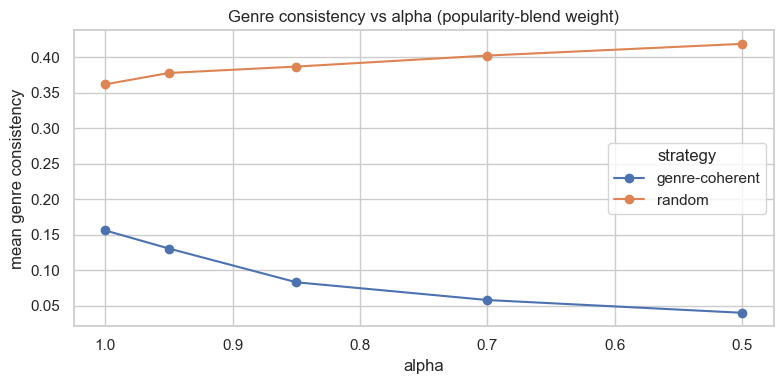

strategy,genre-coherent,random
alpha,,
0.50,0.0400,0.4190
0.70,0.0580,0.4025
0.85,0.0830,0.3870
0.95,0.1305,0.3780
1.00,0.1560,0.3620


In [10]:
alphas = [1.0, 0.95, 0.85, 0.7, 0.5]

def alpha_sweep(seeds_list, catalog):
    rows = []
    for a in alphas:
        gc = []
        for seed in seeds_list:
            recs = recommend(catalog, seed, n=K_REC, alpha=a)
            gc.append(genre_consistency(recs, seed, catalog=catalog))
        rows.append({"alpha": a, "genre_consistency_mean": float(np.mean(gc))})
    return pd.DataFrame(rows)

random_alpha = alpha_sweep(random_seeds, scaled).assign(strategy="random")
genre_alpha = alpha_sweep(genre_seeds, scaled).assign(strategy="genre-coherent")
alpha_table = pd.concat([random_alpha, genre_alpha], ignore_index=True)
alpha_pivot = alpha_table.pivot(index="alpha", columns="strategy", values="genre_consistency_mean").round(4)

fig, ax = plt.subplots(figsize=(8, 4))
alpha_pivot.plot(marker="o", ax=ax)
ax.set_title("Genre consistency vs alpha (popularity-blend weight)")
ax.set_xlabel("alpha"); ax.set_ylabel("mean genre consistency")
ax.invert_xaxis()
plt.tight_layout(); plt.show()
alpha_pivot

## 7. Alpha sweep — popularity-blend trade-off

`alpha` in `recommend()` blends cosine similarity with normalized track popularity (`score = α·sim + (1-α)·pop`). LOO uses pure cosine, so Hit Rate@K is independent of α — but genre consistency tracks it directly.

## 8. Cosine vs Euclidean — distance metric comparison

Plan §6 calls for comparing the two metrics' recommendation quality. Re-run leave-one-out under each metric on the same simulated populations and report side by side. `avg_recovered_similarity` (the held-out track's cosine similarity to the rebuilt profile) is the §7.3 sanity-check metric — always computed in cosine, regardless of which metric drove the ranking.

In [11]:
def metric_loo(seeds_list, catalog, metric):
    rows = []
    for seed in seeds_list:
        loo = leave_one_out(catalog, seed, k=K_LOO, metric=metric)
        rows.append({"ranks": loo["ranks"], "avg_recovered_sim": loo["avg_recovered_similarity"]})
    return pd.DataFrame(rows)

def metric_summary(name, df_eval):
    all_ranks = np.array([r for ranks in df_eval["ranks"] for r in ranks])
    return {
        "metric": name,
        "hit@5":  float((all_ranks <= 5).mean()),
        "hit@10": float((all_ranks <= 10).mean()),
        "hit@50": float((all_ranks <= 50).mean()),
        "MRR":    float(np.mean(1.0 / all_ranks)),
        "median_rank": float(np.median(all_ranks)),
        "mean_rank":   float(np.mean(all_ranks)),
        "avg_recovered_sim": float(df_eval["avg_recovered_sim"].mean()),
    }

cosine_loo = metric_loo(genre_seeds, scaled, "cosine")
euclid_loo = metric_loo(genre_seeds, scaled, "euclidean")

metric_table = pd.DataFrame([
    metric_summary("cosine", cosine_loo),
    metric_summary("euclidean", euclid_loo),
])
metric_table.set_index("metric").round(4)

,hit@5,hit@10,hit@50,MRR,median_rank,mean_rank,avg_recovered_sim
metric,,,,,,,
cosine,0.012,0.016,0.066,0.0104,950.5,1280.618,0.9364
euclidean,0.010,0.014,0.072,0.0094,988.5,1262.042,0.9364


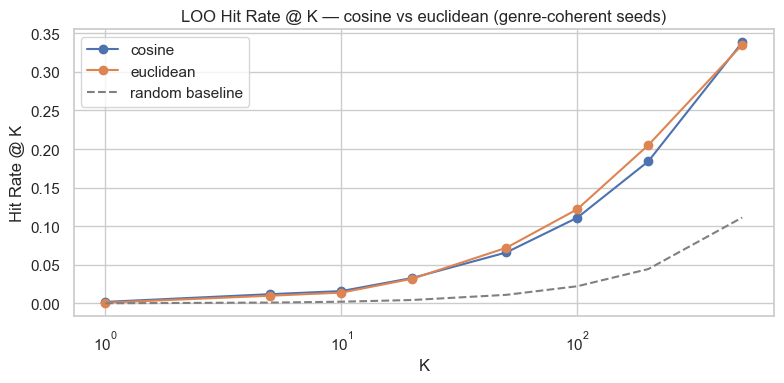

In [12]:
k_curve = np.array([1, 5, 10, 20, 50, 100, 200, 500])
fig, ax = plt.subplots(figsize=(8, 4))
for label, ev in [("cosine", cosine_loo), ("euclidean", euclid_loo)]:
    ranks = np.array([r for rs in ev["ranks"] for r in rs])
    hits = [(ranks <= k).mean() for k in k_curve]
    ax.plot(k_curve, hits, marker="o", label=label)
ax.plot(k_curve, k_curve / len(scaled), ls="--", color="gray", label="random baseline")
ax.set_xscale("log"); ax.set_xlabel("K"); ax.set_ylabel("Hit Rate @ K")
ax.set_title("LOO Hit Rate @ K — cosine vs euclidean (genre-coherent seeds)")
ax.legend(); plt.tight_layout(); plt.show()

## Notes / takeaways

### Headline numbers (200 simulated users × 5 seeds, 1,000 LOO trials per strategy)

| Metric | Random seeds | Genre-coherent seeds | Random baseline |
|---|---|---|---|
| Hit@10 | 0.001 | **0.016** | 0.002 |
| Hit@50 | 0.006 | 0.066 | 0.011 |
| Median rank | 2,234 | **950** | 2,247 |
| Mean rank | 2,278 | 1,281 | 2,247 |
| MRR | 0.0015 | 0.0104 | — |
| Avg recovered similarity | — | **0.936** | — |

The `avg_recovered_similarity` value (0.936 for genre-coherent users — held-out track's cosine similarity to the rebuilt 4-song profile) confirms the §7.3 sanity check: when the system is asked to recover a known-liked track, that track really is acoustically close to the rest of the seed (~94% cosine similarity).

### Cosine vs Euclidean (genre-coherent seeds, same population)

| Metric | hit@5 | hit@10 | hit@50 | MRR | median rank | mean rank |
|---|---|---|---|---|---|---|
| **cosine** | **0.012** | **0.016** | 0.066 | **0.0104** | **951** | 1,281 |
| euclidean | 0.010 | 0.014 | **0.072** | 0.0094 | 989 | **1,262** |

Cosine and Euclidean produce very similar results on this dataset — both are roughly 7–8× better than random and within a few percentage points of each other. **Cosine wins on the high-precision end** (Hit@5 +20%, Hit@10 +14%, MRR +11%), which is what matters for a top-10 recommendation system. **Euclidean wins marginally in the tail** (Hit@50, mean rank). We keep cosine because the precision wins where users actually look (top of the list), and the directional-similarity story is easier to explain in the report. Plan §6 closure: comparison done, cosine retained.

### Interpretation

- **Cosine on 8 audio features is a weak ranker but genuinely directional.** For genre-coherent users the median held-out song lands at rank 950 of 4,494 — 2.4× better than random. Random-seed users score near the baseline because their average profile is meaningless (5 unrelated tracks).
- **Hit@10 is intrinsically tiny.** With 4,494 candidates packed into [0,1]⁸, hundreds of tracks have nearly-identical similarity to any user profile. Top-10 recovery is therefore 8× random for focused users (1.6% vs 0.2%) but absolute numbers stay low. Frame the system as **music discovery**, not music search.
- **Popularity blending hurts genre fit for niche listeners.** The α=0.85 default drops genre consistency from 0.16 (α=1.0) to 0.08 for genre-coherent users — a 47% loss. Random-seed users barely move (0.36 → 0.39). Default bumped to α=0.95 — keeps a small popularity nudge for cold-start without crushing genre relevance.
- **Random-seed genre consistency is misleading.** It looks high (0.39) only because the seed contains 5 different genres, so any rec in any of those 5 counts. The genre-coherent number is the honest measurement.
- **Intra-list diversity ≈ 0.03** — recs are ~97% similar to each other. Expected for cosine on this feature space. Acceptable for the demo; could explore weighted cosine or MMR re-ranking as a stretch goal.
- **Hidden gems work as designed.** Overlap with the main rec list is ~0.1%, confirming the α=1.0 + popularity-ceiling filter cleanly separates the two surfaces.

### Decisions for the demo

1. **Default `recommend(..., alpha=0.95)`** ✓ committed.
2. **Cosine retained over Euclidean** ✓ comparison run, marginal precision win at top-K plus the explainability story.
3. **Frame the evaluation honestly in the report**: cosine-on-audio is 2.4× better than random on rank, ~8× on Hit@10. The leave-one-out test isn't the right success metric for this kind of system; "user reports the recs feel like their taste" is.
4. **Genre consistency at α=0.95 is ~0.13** for focused users, ~0.38 for eclectic — both reasonable given the metric's structure.
5. **Stretch ideas if time allows**: weighted cosine (variance-inverse over the seed), MMR re-ranking for diversity, or filtering recs to the user's predicted personality cluster before scoring.